In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats

In [2]:
### bring all hubgenes
file = './source_data/hubgene/hubgene_533.txt'
hubgene_533 = pd.read_csv(file, sep = '\t', header = 0)

file = './source_data/hubgene/hubgene_19.txt'
hubgene_19 = pd.read_csv(file, sep = '\t', header = 0)

file = './source_data/hubgene/hubgene_60.txt'
hubgene_60 = pd.read_csv(file, sep = '\t', header = 0)


#### cancer gene list
file = './source_data/annotation_files/cancer_gene_census.csv'
cancer_gene = pd.read_csv(file,encoding='latin-1')
cancer_gene['Role'] = cancer_gene['Role in Cancer'].astype(str)
cancer_gene['role_list'] = cancer_gene.Role.str.split(', ')
cancer_gene['oncogene'] = cancer_gene.apply(lambda x: 'Y' if 'oncogene' in x['role_list'] else 'N', axis=1)
cancer_gene['TSG'] = cancer_gene.apply(lambda x: 'Y' if 'TSG' in x['role_list'] else 'N', axis=1)
cancer_gene['fusion'] = cancer_gene.apply(lambda x: 'Y' if 'fusion' in x['role_list'] else 'N', axis=1)

cancer_gene = cancer_gene[['Gene Symbol','oncogene','TSG','fusion']]
cancer_gene = cancer_gene.rename(columns={'Gene Symbol':'gene'})


### bring normalized counts of DEGs
file = './source_data/DEmRNA/batch_cor_TC_pattern_normalized_value.txt'
DE_genes = pd.read_csv(file, sep = '\t', header = 0)


### bring cancer risk factors
path_dir = './source_data/human_geneoutcome_table/'
file_list = os.listdir(path_dir)

Cancer_annot = pd.DataFrame()
for i in file_list:
    if i.startswith('geneoutcome_'):
        file = './source_data/human_geneoutcome_table/%s' % i
        x = pd.read_csv(file, sep = ',', header = 0)
        
        x['cancer_name'] = x['cancer'].str.split(' ').str[0]
        x['-log10_adjP'] = abs(np.log10(x['p']))
        x['n'] = (x['cancer'].str.split(')').str[0]).str.split('=').str[1]
        x['sig'] = x.apply(lambda a : 'S' if a['p'] < 0.05 else 'N',axis=1)
        x['risk'] = x.apply(lambda a : 'IN' if a['z_score'] > 0 else 'DE',axis=1)
        
        x['order'] = i.split('_')[2]
        x['order'] = x['order'].astype(int)
        
        Cancer_annot = Cancer_annot.append(x)

Cancer_annot = Cancer_annot.reset_index(drop=False)
Cancer_annot = Cancer_annot[['cancer','index','order','cancer_name','n','infiltrates','z_score','p','adj.p','sig','risk','-log10_adjP']]


Cancer_annot = Cancer_annot.sort_values(by=['order','index'], ascending=[True,True])
Cancer_annot = Cancer_annot.reset_index(drop=True)

In [3]:
# calculate weight value for cancer ratio

DE_genes['group'] = DE_genes.apply(lambda x : 1 if x['condition'] == 'G1' else 2 if x['condition'] == 'G2' else 3 if x['condition'] == 'G3' else 4, axis=1)
DE_genes= DE_genes.sort_values(by=['group'], ascending=[True])

for i in range(1,8):
    CLUSTER = DE_genes[DE_genes['cluster'] == i]
    r,p = scipy.stats.pearsonr(CLUSTER['group'], CLUSTER['value'])
    globals()["g{}_pearson".format(i)] = r

In [4]:
hub = hubgene_533[['gene','Group','Rank']]
hub  = hub.rename(columns={'gene':'infiltrates'})
MERGE = pd.merge(Cancer_annot,hub,how='left',on='infiltrates')
MERGE = MERGE.sort_values(by=['Group','Rank'], ascending=[True,True])

In [5]:
def cancer_ratio(dt):

    dt['modified_z'] = dt.apply(lambda x : g3_pearson*(x['z_score']) if x['Group'] == 'human_WGCNA_group3' 
                                else g6_pearson*(x['z_score']) if x['Group'] == 'human_WGCNA_group6' 
                                else g2_pearson*x['z_score'] ,axis=1)
    
    dt['c_ratio'] = dt.apply(lambda x : x['modified_z'] if x['sig'] == 'S' else 0 ,axis=1)
    dt_result = dt.groupby(['cancer_name'])['c_ratio'].sum()
    dt_result = pd.DataFrame(dt_result)
    dt_result = dt_result.reset_index(drop=False)

    return dt_result

In [6]:
def dot_graph(dt,plt_command,num,xlim_1,xlim_2,r_num,Grid_num,x_num):
    
    dt = dt.reset_index(drop=True)


    gs = gridspec.GridSpec(1,Grid_num,hspace=0) 
    
    gs0 = gridspec.GridSpecFromSubplotSpec(nrows=2, ncols=num, height_ratios=[0.2,15],width_ratios=[1]*num,hspace=0.02,wspace=0, subplot_spec=gs[0,0:Grid_num-1])
    gs1 = gridspec.GridSpecFromSubplotSpec(nrows=2, ncols=1, height_ratios=[0.2,15],width_ratios=[1],hspace=0.02, subplot_spec=gs[0,Grid_num-1])
    
    n=0
    a=0
    for g in dt['infiltrates'].unique().tolist():
        
        dt_gene = dt[dt['infiltrates'] == g]
        group = dt_gene.iloc[0]['Group']

        globals()['ax{}'.format(n)] = plt.subplot(gs0[0,a])
        plt.xticks([])
        plt.yticks([])
        plt.text(0.5, 0.5, '', ha='center', va='center', size=10)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['left'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['bottom'].set_visible(False)
        if group == 'human_WGCNA_group2':
            plt.gca().set_facecolor('#66c2a5')
        elif group == 'human_WGCNA_group3':
            plt.gca().set_facecolor('#8da0cb')
        elif group == 'human_WGCNA_group6':
            plt.gca().set_facecolor('#deb887')           
        
               
        n+=1
        a+=1 
    
    ax70 = plt.subplot(gs0[1,0:num])

    edgeC = ['red' if dt.iloc[idx]['sig'] == 'S' and dt.iloc[idx]['risk'] == 'IN'
             else 'blue'  if dt.iloc[idx]['sig'] == 'S' and dt.iloc[idx]['risk'] == 'DE' 
             else 'white' for idx in dt.index]

    sns.scatterplot(data=dt, x='infiltrates', y='cancer', hue='z_score',palette='coolwarm',size='-log10_adjP',sizes=(50,300),edgecolor=edgeC, linewidth=2,ax=ax70)
    #ax70.legend(loc='upper right',bbox_to_anchor=(1.52,1),prop={'size':12},frameon=False) 
    #ax70.legend(loc='upper right',bbox_to_anchor=(1.41,1),prop={'size':12},frameon=False)
    ax70.set(xlabel=None)
    ax70.set(ylabel=None)
    ax70.get_legend().remove()
    plt.ylim(40.5,-0.5)
    plt.xlim(-(xlim_1),xlim_2)
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12,rotation=45)
    

    ratio = cancer_ratio(dt)

    col = ['orange' if ratio.iloc[idx]['c_ratio'] > r_num 
           else 'green'  if -(r_num) > ratio.iloc[idx]['c_ratio'] 
           else 'black' for idx in ratio.index]

    ax71 = plt.subplot(gs1[1,0])
    plt.yticks([])
    sns.scatterplot(data=ratio, x='c_ratio', y='cancer_name',palette=['green','black','orange'],hue=col,s=100,ax=ax71)
    ax71.axvline(x=0, color='red',linewidth=1)
    #ax71.legend(loc='upper right',bbox_to_anchor=(2.9,0.62),prop={'size':12},title='age',title_fontsize=12,frameon=False)
    #ax71.legend(loc='upper right',bbox_to_anchor=(2.3,0.62),prop={'size':12},title='age',title_fontsize=12,frameon=False)
    ax71.set(xlabel=None)
    ax71.set(ylabel=None)
    ax71.get_legend().remove()
    plt.ylim(40.5,-0.5)
    plt.xlim(-(x_num),x_num)
    plt.xticks(fontsize=12,rotation=45)
    
    plt.gcf().subplots_adjust(left=0.25,right=0.8)
    plt.show()

    return ratio

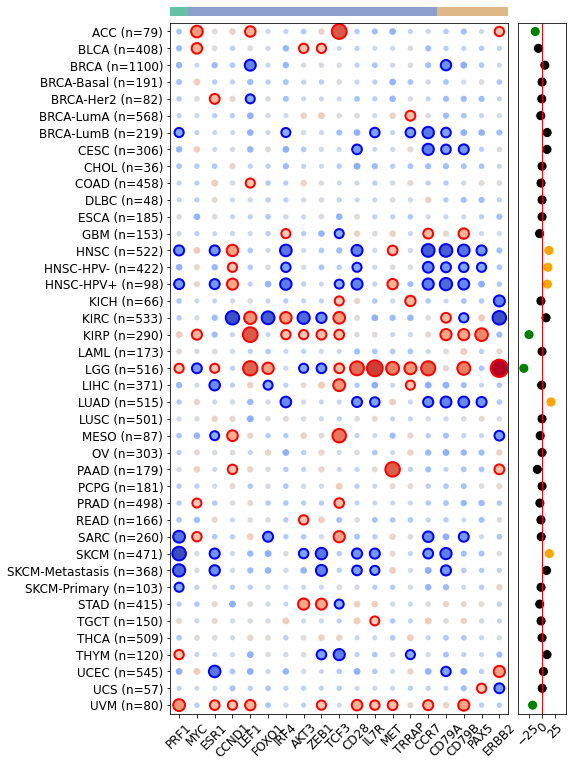

In [7]:
MERGE_19 = MERGE[MERGE['infiltrates'].isin(hubgene_19['gene'].unique())]

ratio = dot_graph(MERGE_19,plt.figure(figsize = (10,13)),19,0.5,18.5,10,7,45)

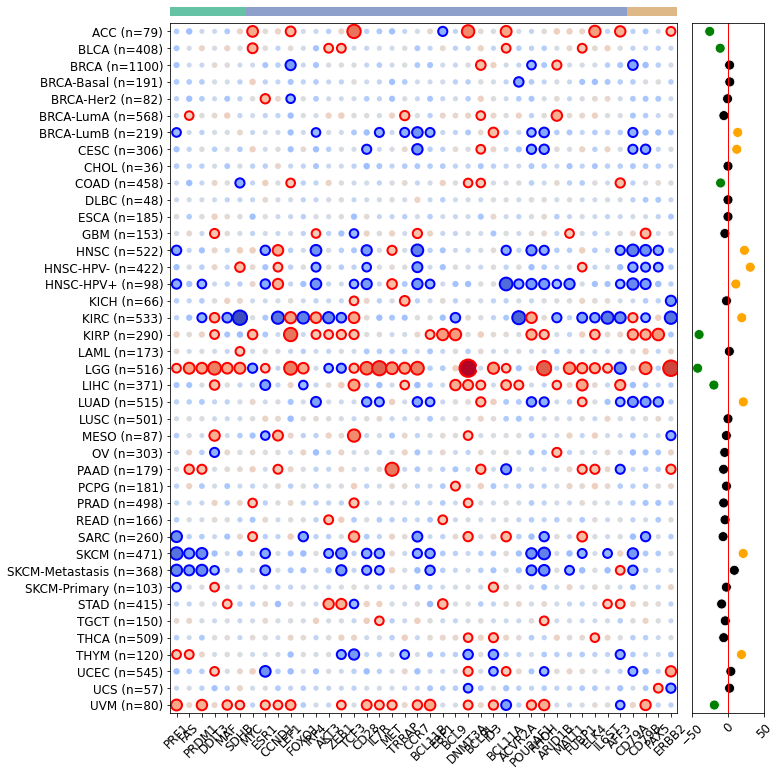

In [8]:
cancer_gene_sel = cancer_gene[(cancer_gene['oncogene'] == 'Y') | (cancer_gene['TSG'] == 'Y')]
MERGE_ALL = MERGE[MERGE['infiltrates'].isin(cancer_gene_sel['gene'])]

ratio = dot_graph(MERGE_ALL,plt.figure(figsize = (15,13)),40,0.5,39.5,10,7,50)
#ratio.to_csv('/home/chm/analyzing_file_byR/RNA/SQuIRE_count_ELTC/Final_data/ARscore_hub40.txt',sep='\t',index=False,header=True)